# Pipeline de Dados - Sistema de Eventos e Festas

Trabalho da disciplina de Extração e Análise de Dados.

Ideia do projeto: pegar 3 fontes diferentes (SQL, JSON e HTML), juntar tudo numa base só, limpar o que tiver de errado e responder algumas perguntas sobre os dados.

## 1. Extração

As 3 fontes: `eventos.sql` (compras), `festas.json.json` (catálogo de festas) e `index.html` (preço atualizado no site).

In [1]:
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup


In [2]:
# fonte 1 - SQL
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

with open("eventos.sql", "r", encoding="utf-8") as f:
    cursor.executescript(f.read())
conn.commit()

df_sql = pd.read_sql("SELECT * FROM compras", conn)
conn.close()

df_sql


,id,usuario,festa_id,nome_festa,quantidade_ingressos
0,1,Ana Souza,1,Neon Party,2
1,2,Bruno Lima,2,Summer Beats,1
2,3,Carla Mendes,3,Funk Night,3
3,4,Diego Alves,4,Open Bar Sunset,2
4,5,Eduarda Rocha,5,Festival Vibes,1
5,6,Felipe Costa,2,Summer Beats,2
6,7,Gabriela Martins,3,funk night,1
7,8,NaN,1,Neon Party,2


In [3]:
# fonte 2 - JSON
with open("festas.json.json", "r", encoding="utf-8") as f:
    dados_json = json.load(f)

df_json = pd.DataFrame(dados_json)
df_json


,id,title,categoria,preco
0,1,Neon Party,Eletrônica,120
1,2,Summer Beats,Open Air,180
2,3,Funk Night,Funk,90
3,4,Open Bar Sunset,Sunset,250
4,5,Festival Vibes,Festival,NaN


In [4]:
# fonte 3 - HTML
# cada card de festa tem um data-id, uso ele em vez do nome pra não dar problema de
# junção depois (nome escrito diferente em cada lugar)
with open("index.html", "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")

registros_html = []
for div in soup.find_all("div", class_="festa"):
    id_festa = int(div["data-id"])
    nome = div.find("h2").text.strip()
    preco_texto = div.find("span", class_="preco").text.replace("R$", "").strip()
    registros_html.append({
        "id_festa": id_festa,
        "nome_festa_site": nome,
        "preco_site": preco_texto
    })

df_html = pd.DataFrame(registros_html)
df_html


,id_festa,nome_festa_site,preco_site
0,1,Neon Party,130
1,2,Summer Beats,190
2,3,Funk Night,95
3,4,Open Bar Sunset,260
4,5,Festival Vibes,???


## 2. Limpeza

Coisas que precisei tratar:
- valor ausente (usuário nulo no SQL, preço nulo no JSON, preço `"???"` no HTML)
- texto bagunçado (espaço sobrando, maiúscula/minúscula diferente)
- tipo errado (preço veio como texto e precisa virar número)
- o id da festa, que é o ponto mais importante pra não bugar o merge depois

### sobre o id da festa

Na primeira versão eu tinha renomeado `festa_id` pra `festa`, só que o JSON também tem uma coluna de nome que eu ia chamar de `festa`. Ficava uma coluna numérica e uma de texto com o mesmo nome, e isso quebrava o merge (o professor pegou esse erro).

Corrigi mantendo o id numérico sempre como `id_festa` em todas as fontes, e o nome da festa em colunas separadas (`nome_festa`, `nome_festa_api`, `nome_festa_site`) só pra referência, sem usar ele pra dar merge.

In [5]:
# limpeza df_sql

df_sql["usuario"] = df_sql["usuario"].fillna("Desconhecido")

df_sql["nome_festa"] = df_sql["nome_festa"].str.strip().str.title()

df_sql = df_sql.rename(columns={"festa_id": "id_festa"})

df_sql


,id,usuario,id_festa,nome_festa,quantidade_ingressos
0,1,Ana Souza,1,Neon Party,2
1,2,Bruno Lima,2,Summer Beats,1
2,3,Carla Mendes,3,Funk Night,3
3,4,Diego Alves,4,Open Bar Sunset,2
4,5,Eduarda Rocha,5,Festival Vibes,1
5,6,Felipe Costa,2,Summer Beats,2
6,7,Gabriela Martins,3,Funk Night,1
7,8,Desconhecido,1,Neon Party,2


In [6]:
# limpeza df_json

df_json["preco"] = pd.to_numeric(df_json["preco"], errors="coerce")
df_json["preco"] = df_json["preco"].fillna(df_json["preco"].mean())  # imputa pela média

df_json = df_json.rename(columns={
    "id": "id_festa",
    "title": "nome_festa_api",
    "preco": "preco_api"
})
df_json["nome_festa_api"] = df_json["nome_festa_api"].str.strip().str.title()

df_json


,id_festa,nome_festa_api,categoria,preco_api
0,1,Neon Party,Eletrônica,120.0
1,2,Summer Beats,Open Air,180.0
2,3,Funk Night,Funk,90.0
3,4,Open Bar Sunset,Sunset,250.0
4,5,Festival Vibes,Festival,160.0


In [7]:
# limpeza df_html

# o "R$ ???" some sozinho aqui, vira NaN
df_html["preco_site"] = pd.to_numeric(df_html["preco_site"], errors="coerce")
df_html["preco_site"] = df_html["preco_site"].fillna(df_html["preco_site"].mean())

df_html = df_html.rename(columns={"preco_site": "preco_html"})
df_html["nome_festa_site"] = df_html["nome_festa_site"].str.strip().str.title()

df_html


,id_festa,nome_festa_site,preco_html
0,1,Neon Party,130.00
1,2,Summer Beats,190.00
2,3,Funk Night,95.00
3,4,Open Bar Sunset,260.00
4,5,Festival Vibes,168.75


## 3. Integração

Junto as 3 fontes usando `id_festa`. Antes eu só tinha unido JSON com HTML e esquecido o SQL - por isso faltavam as colunas `usuario` e `quantidade_ingressos` no resultado final.

In [8]:
df = df_sql.merge(df_json[["id_festa", "categoria", "preco_api"]], on="id_festa", how="left")
df = df.merge(df_html[["id_festa", "preco_html"]], on="id_festa", how="left")

df


,id,usuario,id_festa,nome_festa,quantidade_ingressos,categoria,preco_api,preco_html
0,1,Ana Souza,1,Neon Party,2,Eletrônica,120.0,130.00
1,2,Bruno Lima,2,Summer Beats,1,Open Air,180.0,190.00
2,3,Carla Mendes,3,Funk Night,3,Funk,90.0,95.00
3,4,Diego Alves,4,Open Bar Sunset,2,Sunset,250.0,260.00
4,5,Eduarda Rocha,5,Festival Vibes,1,Festival,160.0,168.75
5,6,Felipe Costa,2,Summer Beats,2,Open Air,180.0,190.00
6,7,Gabriela Martins,3,Funk Night,1,Funk,90.0,95.00
7,8,Desconhecido,1,Neon Party,2,Eletrônica,120.0,130.00


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8 non-null      int64  
 1   usuario               8 non-null      str    
 2   id_festa              8 non-null      int64  
 3   nome_festa            8 non-null      str    
 4   quantidade_ingressos  8 non-null      int64  
 5   categoria             8 non-null      str    
 6   preco_api             8 non-null      float64
 7   preco_html            8 non-null      float64
dtypes: float64(2), int64(3), str(3)
memory usage: 644.0 bytes


## 4. Transformação

Criando as colunas novas que o trabalho pede (pelo menos 5).

In [10]:
# 1 - quanto foi gasto em cada compra
df["valor_gasto"] = df["quantidade_ingressos"] * df["preco_api"]

# 2 - diferença de preço entre API e site
df["diferenca_preco"] = df["preco_html"] - df["preco_api"]

# 3 - preço médio das duas fontes
df["preco_medio"] = df[["preco_api", "preco_html"]].mean(axis=1)

# 4 - faixa de preço
df["faixa_preco"] = pd.cut(
    df["preco_api"],
    bins=[0, 100, 200, float("inf")],
    labels=["Barato", "Médio", "Caro"]
)

# 5 - preço normalizado (0 a 1)
minimo, maximo = df["preco_api"].min(), df["preco_api"].max()
df["preco_api_normalizado"] = (df["preco_api"] - minimo) / (maximo - minimo)

df


,id,usuario,id_festa,nome_festa,quantidade_ingressos,categoria,preco_api,preco_html,valor_gasto,diferenca_preco,preco_medio,faixa_preco,preco_api_normalizado
0,1,Ana Souza,1,Neon Party,2,Eletrônica,120.0,130.00,240.0,10.00,125.000,Médio,0.1875
1,2,Bruno Lima,2,Summer Beats,1,Open Air,180.0,190.00,180.0,10.00,185.000,Médio,0.5625
2,3,Carla Mendes,3,Funk Night,3,Funk,90.0,95.00,270.0,5.00,92.500,Barato,0.0000
3,4,Diego Alves,4,Open Bar Sunset,2,Sunset,250.0,260.00,500.0,10.00,255.000,Caro,1.0000
4,5,Eduarda Rocha,5,Festival Vibes,1,Festival,160.0,168.75,160.0,8.75,164.375,Médio,0.4375
5,6,Felipe Costa,2,Summer Beats,2,Open Air,180.0,190.00,360.0,10.00,185.000,Médio,0.5625
6,7,Gabriela Martins,3,Funk Night,1,Funk,90.0,95.00,90.0,5.00,92.500,Barato,0.0000
7,8,Desconhecido,1,Neon Party,2,Eletrônica,120.0,130.00,240.0,10.00,125.000,Médio,0.1875


## 5. Análise Exploratória

In [11]:
df[["preco_api", "preco_html", "valor_gasto"]].describe()


,preco_api,preco_html,valor_gasto
count,8.000000,8.000000,8.00000
mean,148.750000,157.343750,255.00000
std,54.625347,56.150458,127.39141
min,90.000000,95.000000,90.00000
25%,112.500000,121.250000,175.00000
50%,140.000000,149.375000,240.00000
75%,180.000000,190.000000,292.50000
max,250.000000,260.000000,500.00000


In [12]:
gasto_por_usuario = df.groupby("usuario")["valor_gasto"].sum().sort_values(ascending=False)
gasto_por_usuario


usuario
Diego Alves         500.0
Felipe Costa        360.0
Carla Mendes        270.0
Ana Souza           240.0
Desconhecido        240.0
Bruno Lima          180.0
Eduarda Rocha       160.0
Gabriela Martins     90.0
Name: valor_gasto, dtype: float64

In [13]:
ingressos_por_festa = df.groupby("nome_festa")["quantidade_ingressos"].sum().sort_values(ascending=False)
ingressos_por_festa


nome_festa
Funk Night         4
Neon Party         4
Summer Beats       3
Open Bar Sunset    2
Festival Vibes     1
Name: quantidade_ingressos, dtype: int64

In [14]:
df[["preco_api", "quantidade_ingressos"]].corr()


,preco_api,quantidade_ingressos
preco_api,1.000000,-0.157185
quantidade_ingressos,-0.157185,1.000000


### Outliers (extra)

Usando IQR em cima do preço da API.

In [15]:
Q1 = df_json["preco_api"].quantile(0.25)
Q3 = df_json["preco_api"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_json[(df_json["preco_api"] < limite_inferior) | (df_json["preco_api"] > limite_superior)]
outliers if not outliers.empty else "sem outliers nessa amostra"


'sem outliers nessa amostra'

## 6. Gráficos

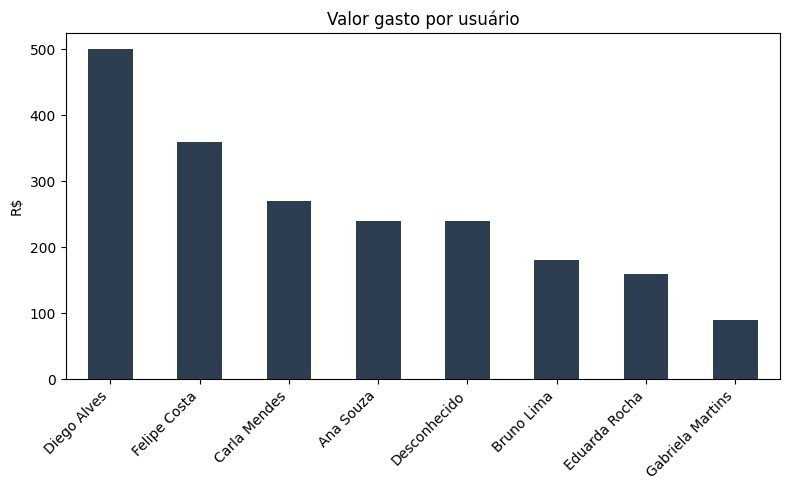

In [16]:
plt.figure(figsize=(8, 5))
gasto_por_usuario.plot(kind="bar", color="#2c3e50")
plt.title("Valor gasto por usuário")
plt.ylabel("R$")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


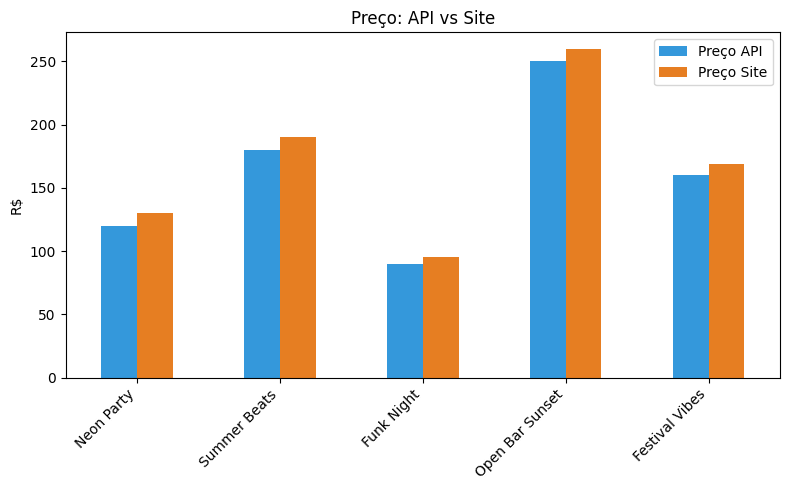

In [17]:
comparacao = pd.DataFrame({
    "Preço API": df_json.set_index("nome_festa_api")["preco_api"],
    "Preço Site": df_html.set_index("nome_festa_site")["preco_html"]
})

comparacao.plot(kind="bar", figsize=(8, 5), color=["#3498db", "#e67e22"])
plt.title("Preço: API vs Site")
plt.ylabel("R$")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


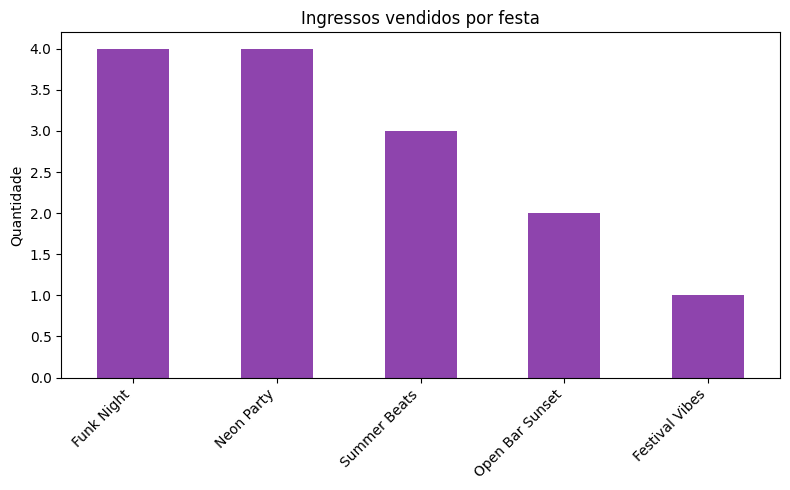

In [18]:
plt.figure(figsize=(8, 5))
ingressos_por_festa.plot(kind="bar", color="#8e44ad")
plt.title("Ingressos vendidos por festa")
plt.ylabel("Quantidade")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 7. Dashboard

Os 3 gráficos juntos num painel só, que era um dos pedidos do trabalho.

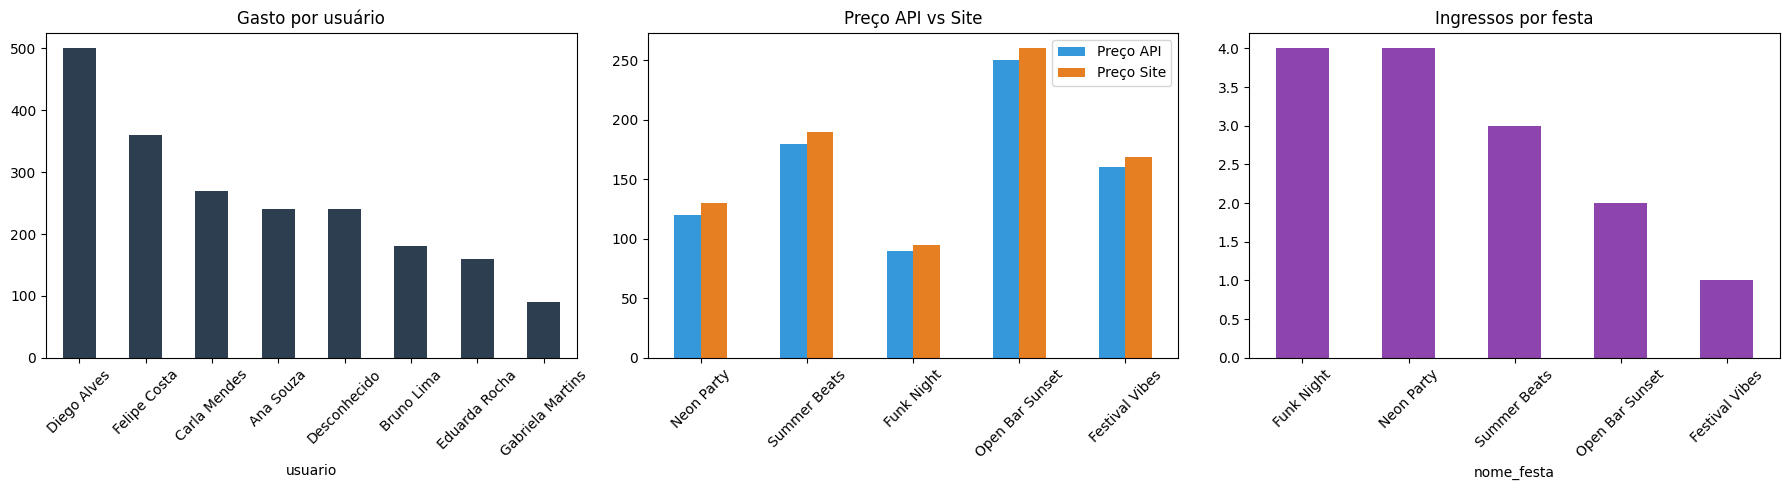

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gasto_por_usuario.plot(kind="bar", ax=axes[0], color="#2c3e50")
axes[0].set_title("Gasto por usuário")
axes[0].tick_params(axis="x", rotation=45)

comparacao.plot(kind="bar", ax=axes[1], color=["#3498db", "#e67e22"])
axes[1].set_title("Preço API vs Site")
axes[1].tick_params(axis="x", rotation=45)

ingressos_por_festa.plot(kind="bar", ax=axes[2], color="#8e44ad")
axes[2].set_title("Ingressos por festa")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Respostas do trabalho

In [20]:
usuario_mais_gastou = gasto_por_usuario.idxmax()
valor_mais_gastou = gasto_por_usuario.max()

festa_mais_vendida = ingressos_por_festa.idxmax()
qtd_mais_vendida = ingressos_por_festa.max()

media_gasto = df["valor_gasto"].mean()
diferenca_media = df["diferenca_preco"].mean()

categoria_top = df.sort_values("valor_gasto", ascending=False).iloc[0]["categoria"]

print("RESPOSTAS")
print(f"1) Usuário que mais gastou: {usuario_mais_gastou} (R$ {valor_mais_gastou:.2f})")
print(f"2) Festa mais vendida: {festa_mais_vendida} ({qtd_mais_vendida} ingressos)")
print(f"3) Média de gasto por compra: R$ {media_gasto:.2f}")
print(f"4) Diferença média de preço (API x site): R$ {diferenca_media:.2f}")
print(f"5) Categoria com mais gasto: {categoria_top}")


RESPOSTAS
1) Usuário que mais gastou: Diego Alves (R$ 500.00)
2) Festa mais vendida: Funk Night (4 ingressos)
3) Média de gasto por compra: R$ 255.00
4) Diferença média de preço (API x site): R$ 8.59
5) Categoria com mais gasto: Sunset


### Ranking de usuários (extra)

In [21]:
ranking = gasto_por_usuario.reset_index()
ranking.index = ranking.index + 1
ranking.columns = ["usuario", "valor_gasto"]
ranking


,usuario,valor_gasto
1,Diego Alves,500.0
2,Felipe Costa,360.0
3,Carla Mendes,270.0
4,Ana Souza,240.0
5,Desconhecido,240.0
6,Bruno Lima,180.0
7,Eduarda Rocha,160.0
8,Gabriela Martins,90.0


## Conclusão

Depois de corrigir o id da festa e juntar as 3 fontes direito, deu pra trazer usuário e quantidade de ingressos pro resultado final (que antes estava faltando) e responder as perguntas do trabalho. Também apliquei os itens extras: gráfico, ranking, outlier e normalização.